# Neural Network in GW detectability

Moving from the problem in Exercise 20, let's see if we can predict detectability training a neural network.

In [1]:
import tensorflow as tf
from tensorflow import keras

In [83]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.12.0
GPU: []


In [84]:
import numpy as np
import matplotlib.pyplot as plt

In [102]:
np.random.seed(1234)
tf.random.set_seed(1234)

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [104]:
def rescaling(x, min_val, max_val):
    return 2. * ((x - min_val) / (max_val - min_val)) - 1.

In [105]:
def trainnetwork(input, output, epochs, filename):

    # cross validation split
    input_train, input_test, output_train, output_test = train_test_split(input, output, test_size=0.2, random_state=42)

    # initializer
    init = keras.initializers.glorot_uniform(seed=1234)

    #model
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(len(input[0]),)),
        keras.layers.Dense(8, activation='relu', kernel_initializer=init, kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(4, activation='relu', kernel_initializer=init, kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(1, activation='sigmoid', kernel_initializer=init)
    ])

    # learning rate scheduler
    def scheduler(epoch, lr):
        if epoch < 50:
            return lr
        else:
            return lr * tf.math.exp(-0.05)
        
    # class weight function
    def class_weight(y):
        from sklearn.utils import class_weight
        class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
        return dict(enumerate(class_weights))

    # compile the model
    model.compile(
            optimizer=keras.optimizers.legacy.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=[keras.metrics.Precision(),keras.metrics.Recall(), keras.metrics.AUC()]
    )
    
    # fit the model
    history = model.fit(
            input_train, 
            output_train,   
            validation_data=(input_test, output_test),
            batch_size=20,       
            epochs=epochs,  
            class_weight = class_weight(output_train), 
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=30,
                    restore_best_weights=True),
                keras.callbacks.ModelCheckpoint(
                    filepath=filename,
                    save_weights_only=False,
                    monitor='val_loss',
                    mode='max',
                    save_best_only=True),
                keras.callbacks.LearningRateScheduler(scheduler),
                keras.callbacks.TensorBoard(log_dir="logs" + filename.split('.h5')[0], histogram_freq=1)
            ],
            shuffle=True,
            verbose=0            #shorter output
        )
    
    return model, history

In [106]:
import h5py

path = "/Users/ffara/Desktop/LML/astrostatistics_bicocca_2025/exercise/sample_2e7_design_precessing_higherordermodes_3detectors.h5"
with h5py.File(path, 'r') as f:
    fin = {key: f[key][()] for key in f.keys()}

In [107]:
N_lim = 1000000
N_epochs = 100

data = {k: v[:N_lim] for k, v in fin.items()}
len(data['q'])

1000000

In [108]:
Y = data['det']

X = np.column_stack([
    data['q'],
    data['mtot'],
    data['iota'],
    data['ra'],
    data['dec'],
    data['psi'],
    data['chi1x'],
    data['chi1y'],
    data['chi1z'],
    data['chi2x'],
    data['chi2y'],
    data['chi2z'],
    data['z'],
    # data['snr'],
])

In [109]:
X = rescaling(X, np.min(X, axis=0), np.max(X, axis=0))

In [110]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [111]:
model, history = trainnetwork(X_train, Y_train, N_epochs, filename="trained22.h5")

In [112]:
print(history.history.keys())

dict_keys(['loss', 'precision_8', 'recall_8', 'auc_8', 'val_loss', 'val_precision_8', 'val_recall_8', 'val_auc_8', 'lr'])


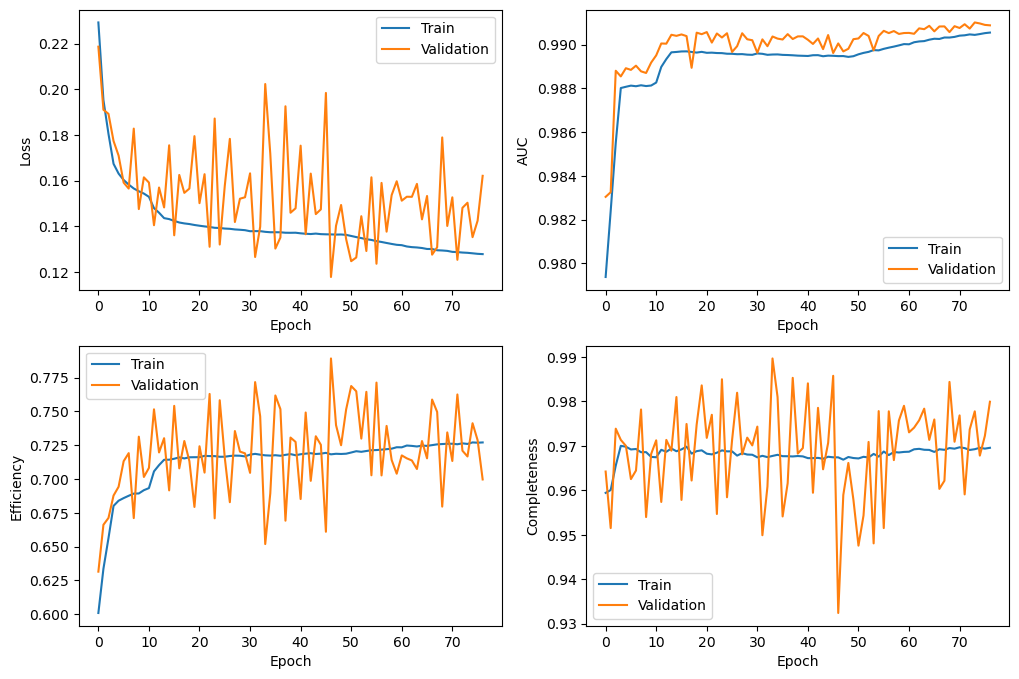

In [114]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0][0].plot(history.history['loss'], label='Train')
ax[0][0].plot(history.history['val_loss'], label='Validation')
ax[0][0].set_xlabel("Epoch")
ax[0][0].set_ylabel("Loss")
ax[0][0].legend()

ax[0][1].plot(history.history['auc_8'], label='Train')
ax[0][1].plot(history.history['val_auc_8'], label='Validation')
ax[0][1].set_xlabel("Epoch")
ax[0][1].set_ylabel("AUC")
ax[0][1].legend()

ax[1][0].plot(history.history['precision_8'], label='Train')
ax[1][0].plot(history.history['val_precision_8'], label='Validation')
ax[1][0].set_xlabel("Epoch")
ax[1][0].set_ylabel("Efficiency")
ax[1][0].legend()

ax[1][1].plot(history.history['recall_8'], label='Train')
ax[1][1].plot(history.history['val_recall_8'], label='Validation')
ax[1][1].set_xlabel("Epoch")
ax[1][1].set_ylabel("Completeness")
ax[1][1].legend()

tight_layout = True

In [ ]:
# NN = keras.models.load_model("trained22.h5")
# print(NN.summary())

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 8)                 64        
                                                                 
 dense_15 (Dense)            (None, 4)                 36        
                                                                 
 dense_16 (Dense)            (None, 1)                 5         
                                                                 
Total params: 105
Trainable params: 105
Non-trainable params: 0
_________________________________________________________________
None


7813/7813 [==============================] - 2s 304us/step


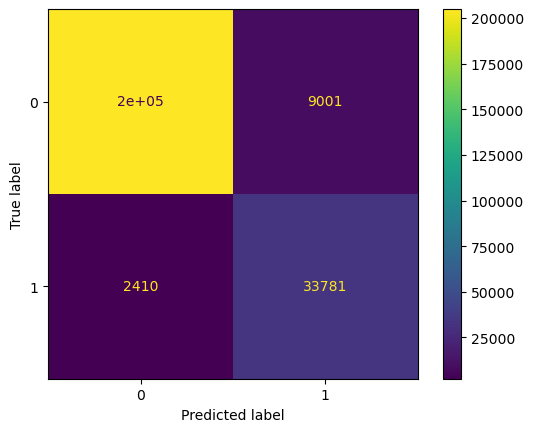

In [115]:
# y_pred = NN.predict(X_test)

Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred.round())
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [116]:
accuracy = cm.diagonal().sum() / cm.sum()
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9544
